In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
x = np.linspace(-5.0,5.0,100)
y = np.sqrt(10**2-x**2)
y = np.hstack([y,-y])
x = np.hstack([x,-x])

In [11]:
x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(5**2-x1**2)
y1= np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

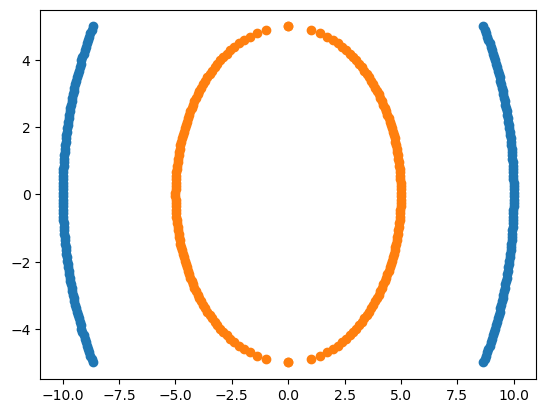

In [12]:
plt.scatter(y,x)
plt.scatter(y1,x1)

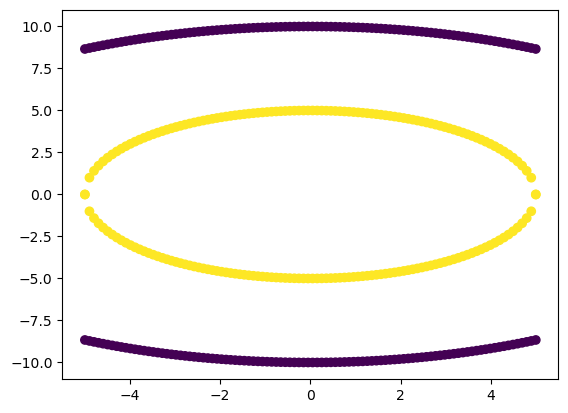

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# outer circle
x = np.linspace(-5,5,100)
y = np.sqrt(10**2 - x**2)

y = np.hstack([y,-y])
x = np.hstack([x,-x])

# inner circle
x1 = np.linspace(-5,5,100)
y1 = np.sqrt(5**2 - x1**2)

y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

# combine
X = np.vstack([
    np.column_stack([x,y]),
    np.column_stack([x1,y1])
])

y_labels = np.array([0]*len(x) + [1]*len(x1))

plt.scatter(X[:,0], X[:,1], c=y_labels)
plt.show()

In [14]:
from sklearn.svm import SVC

model_linear = SVC(kernel='linear')
model_linear.fit(X, y_labels)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [15]:
model_poly = SVC(kernel='poly', degree=2)
model_poly.fit(X, y_labels)

,C,1.0
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
model_rbf = SVC(kernel='rbf')

model_rbf.fit(X, y_labels)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
model_sigmoid = SVC(kernel='sigmoid')
model_sigmoid.fit(X, y_labels)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
def plot_decision_boundary(model, X, y):
    h = 0.1
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(np.arange(x_min,x_max,h),
                         np.arange(y_min,y_max,h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.show()

Linear


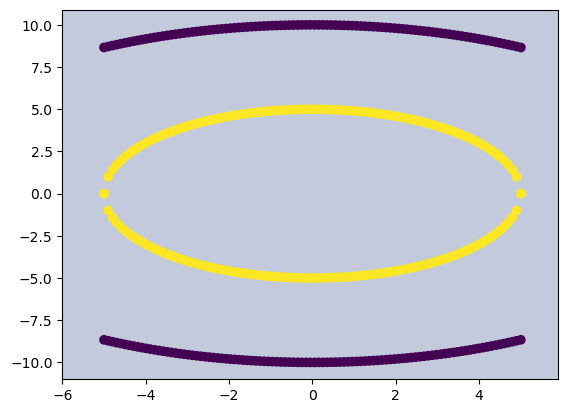

Poly (deg=2)


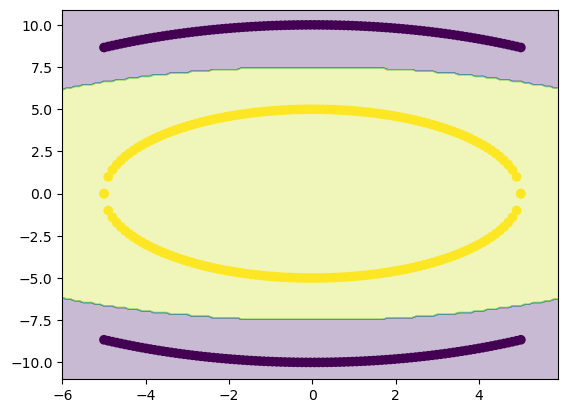

RBF


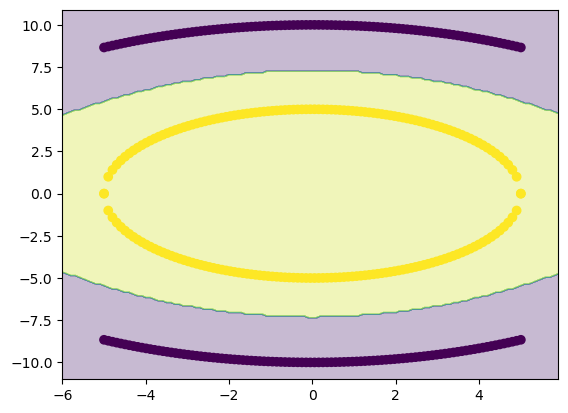

Sigmoid


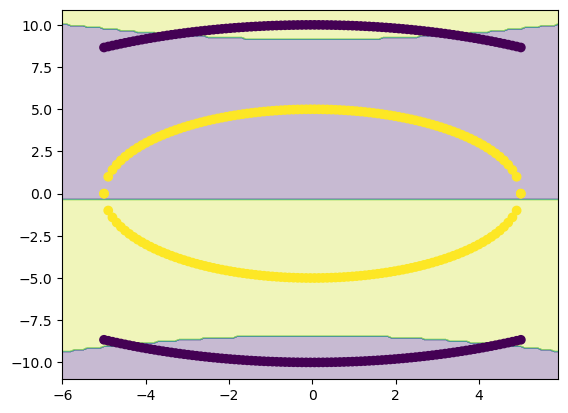

In [19]:
models = {
    "Linear": SVC(kernel='linear'),
    "Poly (deg=2)": SVC(kernel='poly', degree=2),
    "RBF": SVC(kernel='rbf'),
    "Sigmoid": SVC(kernel='sigmoid')
}

for name, model in models.items():
    model.fit(X, y_labels)
    print(name)
    
    plot_decision_boundary(model, X, y_labels)

C=0.1, gamma=0.01


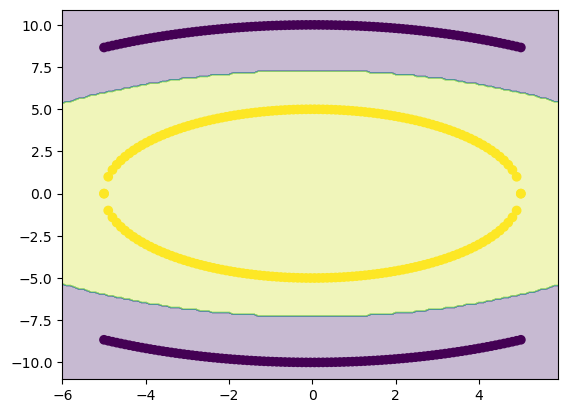

C=0.1, gamma=1


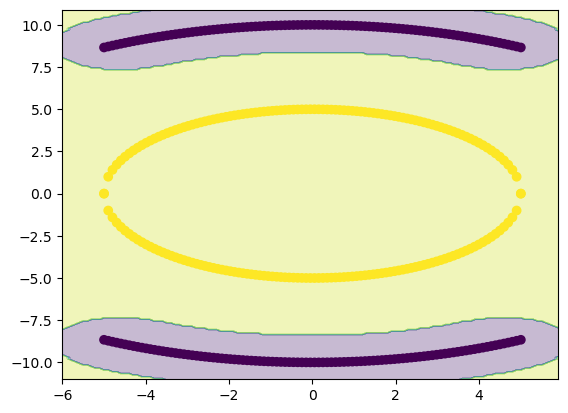

C=0.1, gamma=10


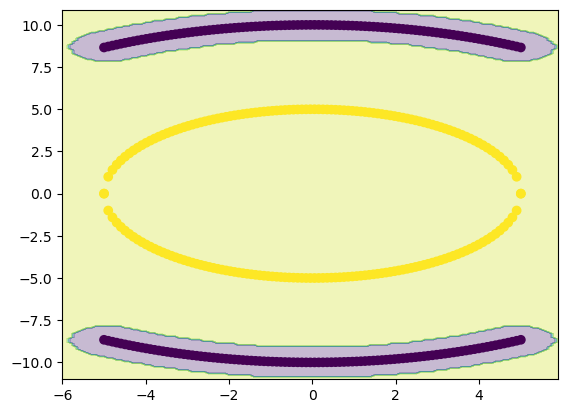

C=1, gamma=0.01


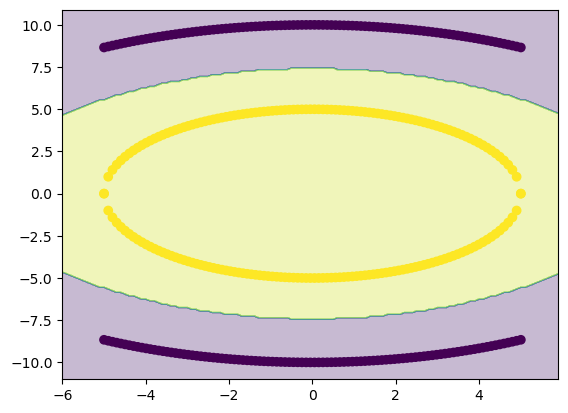

C=1, gamma=1


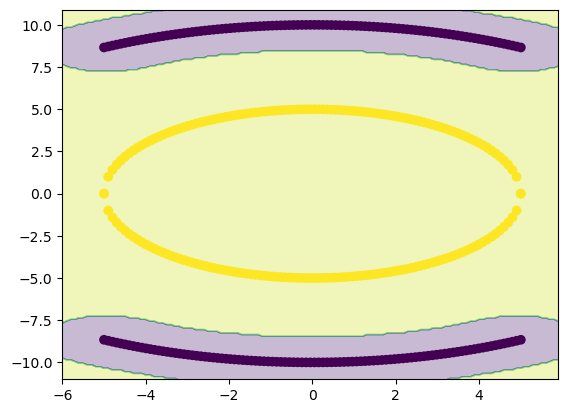

C=1, gamma=10


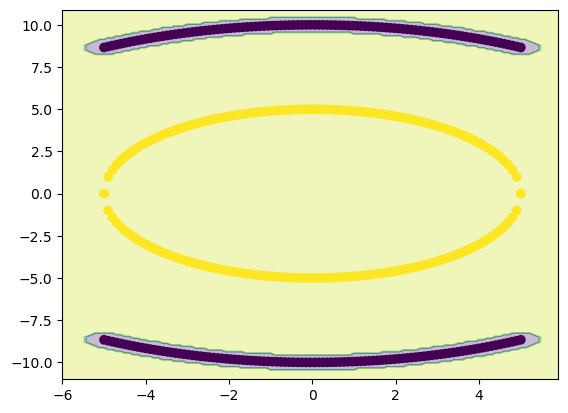

C=100, gamma=0.01


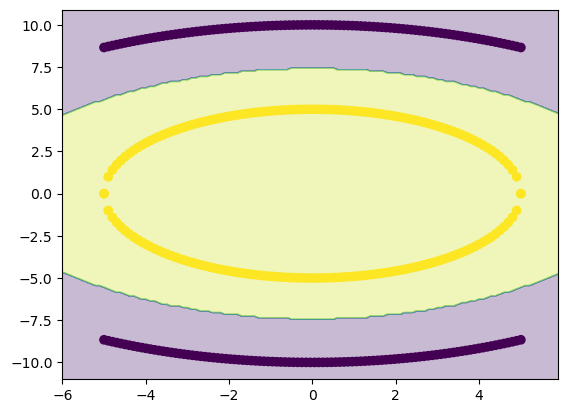

C=100, gamma=1


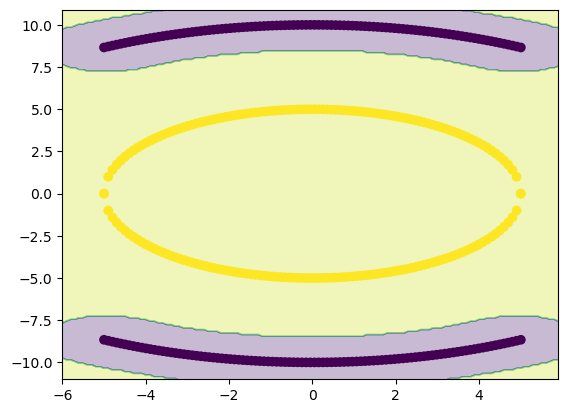

C=100, gamma=10


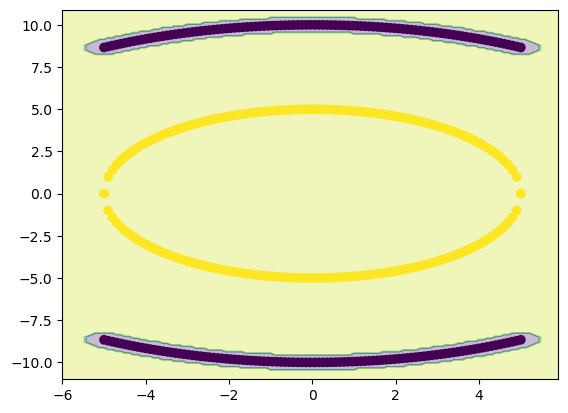

In [20]:
C_values = [0.1, 1, 100]
gamma_values = [0.01, 1, 10]

for C in C_values:
    for gamma in gamma_values:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X, y_labels)
        
        print(f"C={C}, gamma={gamma}")
        
        plot_decision_boundary(model, X, y_labels)

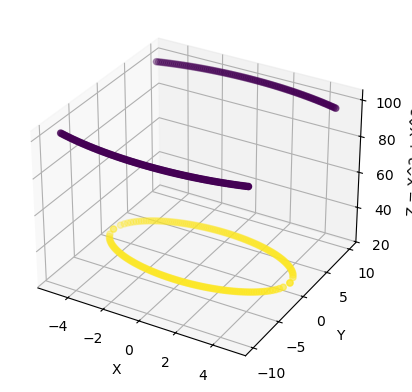

In [ ]:
# same data
x = np.linspace(-5,5,100)
y = np.sqrt(10**2 - x**2)

y = np.hstack([y,-y])
x = np.hstack([x,-x])

x1 = np.linspace(-5,5,100)
y1 = np.sqrt(5**2 - x1**2)

y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

# combine
X_outer = np.column_stack([x,y])
X_inner = np.column_stack([x1,y1])

X = np.vstack([X_outer, X_inner])
y_labels = np.array([0]*len(X_outer) + [1]*len(X_inner))

# transformation (kernel idea)
Z = X[:,0]**2 + X[:,1]**2

# 3D plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,0], X[:,1], Z, c=y_labels)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z = X^2 + Y^2')

plt.show()

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': [0.01, 0.1, 1]
}

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

pipeline = Pipeline([
    ('svc', SVC(kernel='rbf'))
])

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X, y_labels)

print(grid.best_params_)

{'svc__C': 0.1, 'svc__gamma': 0.01}


In [26]:
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

c:\Users\Eng\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Eng\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Eng\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Eng\anaconda3\Lib\site-packages\sklearn\svm\_base.py", line 207, in fit
    y = self._validate_targets(y)
  

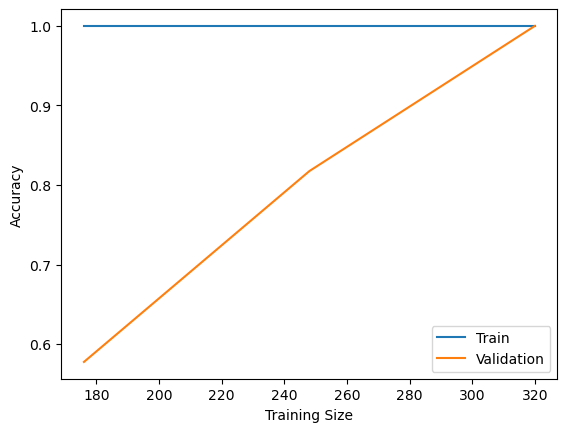

In [27]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='rbf', C=1, gamma=0.1),
    X, y_labels,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()